<a href="https://colab.research.google.com/github/eospgonz10/statistical_analytics_homicide/blob/main/sesiones_practicas/sp_2_juan_jose_garcia_alvarez_estiven_ospina_gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>


## <span style="color:black;"><strong>Datos de los estudiantes</strong></span>

In [5]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

📝 Ingresa tu nombre completo: Estiven Ospina González
📧 Ingresa tu correo electrónico: estiven.ospinag@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de tu cédula: 711784


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

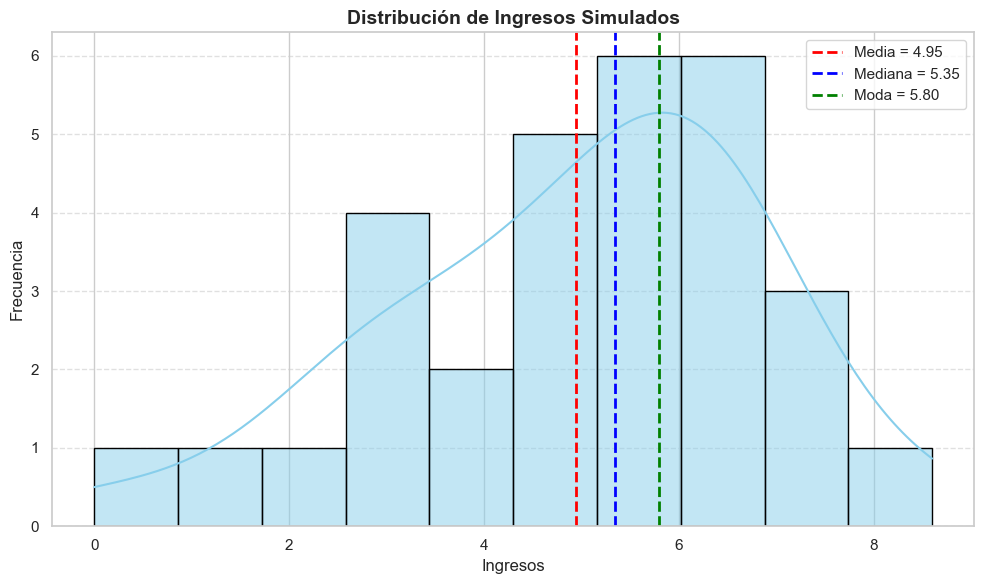

####Medidas de tendencia cental




In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

semilla = int(cedula)
np.random.seed(semilla)

media_proyectada = (semilla % 10 ) + 2
dstd = 2
numero_elementos = 30

simulacion_proyectada = np.random.normal(media_proyectada, dstd, numero_elementos)

media = np.mean(simulacion_proyectada)
mediana = np.median(simulacion_proyectada)
moda = stats.mode(simulacion_proyectada, keepdims=True)[0][0]

print(simulacion_proyectada)
# Resultados
print("Medidas de tendencia central:")
print(f"Media:   {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda:    {moda:.2f}")

[4.91327914 4.4004927  6.02932258 4.10380645 6.63260745 5.83444583
 5.59931614 3.10799007 6.09091203 3.69721691 5.79180377 8.17237358
 6.92274764 7.07644377 4.01979194 3.62210651 6.73545717 5.47079957
 5.11754597 5.85567833 4.59597181 6.60028404 5.09541461 4.16935875
 5.49584375 6.77524929 4.34608702 8.21387946 3.2863411  6.2261994 ]
Medidas de tendencia central:
Media:   5.47
Mediana: 5.55
Moda:    3.11


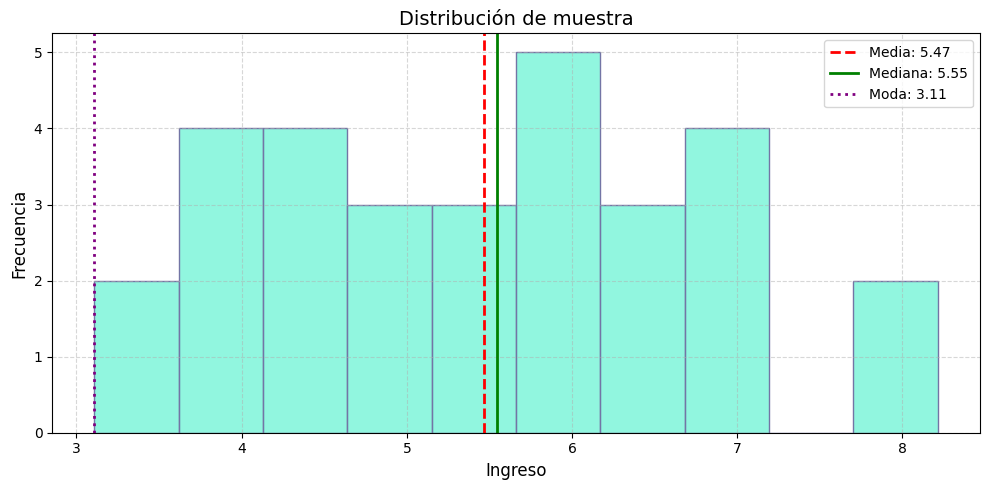

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(simulacion_proyectada, bins=10, kde=False, color="#6cf3d5", edgecolor = '#7375a5')

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

plt.title("Distribución de muestra", fontsize=14)
plt.xlabel("Ingreso", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**La media y la mediana son muy similares**
Esto indica que la distribución es *bastante simétrica* respecto a la media. Cuando media ≈ mediana, normalmente no hay un sesgo fuerte hacia la derecha o izquierda.
1.   **Media**: Aunque la media proyectada era 6, la muestra dio ≈ 5.47.
Esto ocurre porque:

Es una muestra pequeña (n=30)

Existe variabilidad aleatoria en la simulación

2.   **Moda**: No es muy representativa, La gráfica muestra: Moda ≈ 3.11

En datos continuos simulados con distribución normal: Es muy raro que haya valores repetidos exactos.

'stats.mode()' en variables continuas no suele ser una buena medida.


Esa “moda” realmente es solo el valor mínimo repetido o el primero detectado.

En distribuciones normales continuas, la moda teórica debería coincidir con la media (≈ 6).

***Conclusión final***:
La gráfica muestra una distribución *aproximadamente normal*, centrada alrededor de 5.5–6, con dispersión moderada.

Las diferencias entre la media teórica (6) y la observada (5.47) se deben al tamaño de muestra relativamente pequeño.

Si aumentara numero_elementos a 1000 o más, observaría probablemente:

Media más cercana a 6

Mediana más cercana a 6

Histograma más suave y simétrico




### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

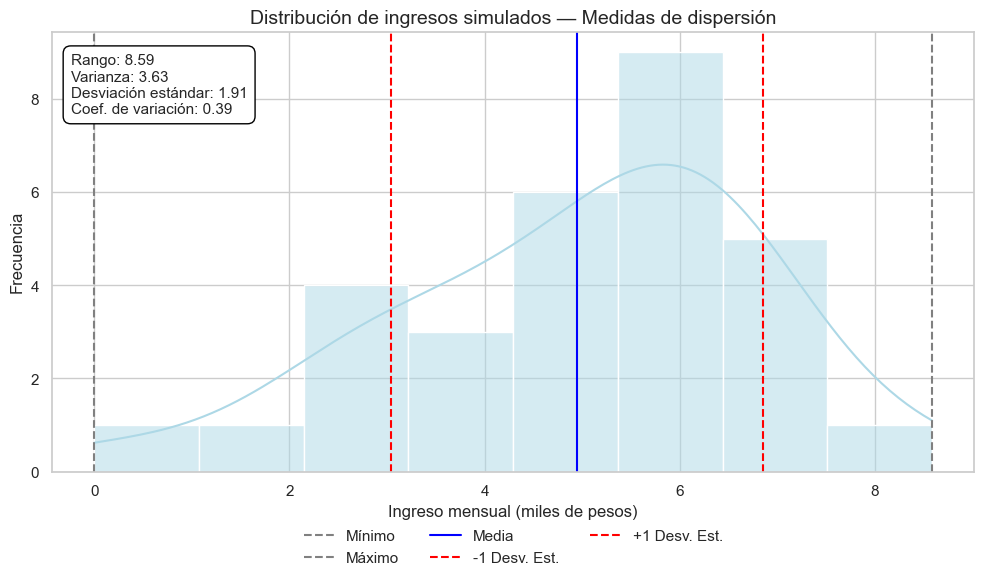

####Cálculo de medidas de dispersión

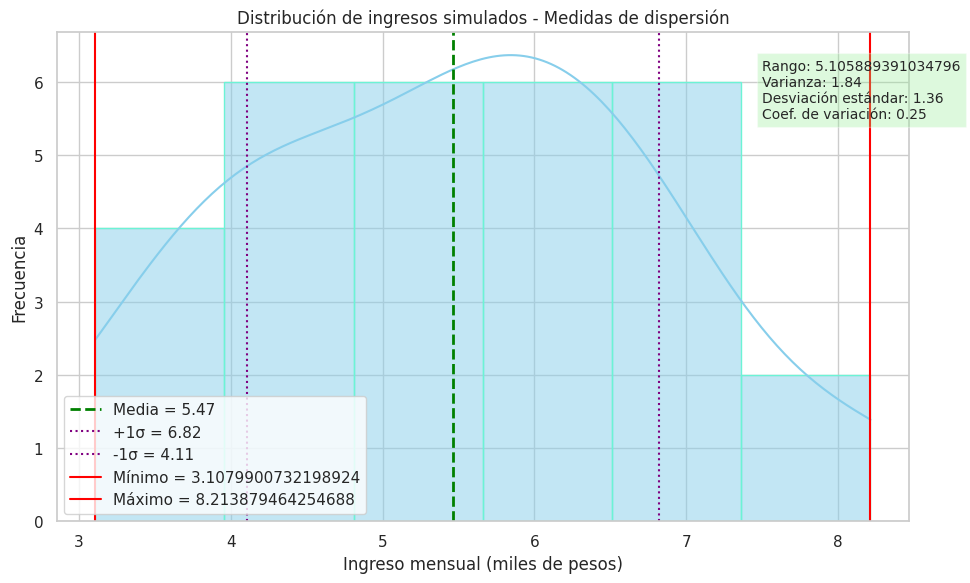

In [10]:
# Cálculo de medidas de dispersión
minimo = np.min(simulacion_proyectada)
maximo = np.max(simulacion_proyectada)
rango = maximo - minimo
varianza = np.var(simulacion_proyectada, ddof=1)
desviacion = np.std(simulacion_proyectada, ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(simulacion_proyectada, bins=6, kde=True, color='skyblue', edgecolor = '#6cf3d5')

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de ingresos simulados - Medidas de dispersión")
plt.xlabel("Ingreso mensual (miles de pesos)")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(7.5, 5.5, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()


**Análisis:**
La distribución muestra ingresos mensuales con media de 5,470 y una desviación estándar de 1.36, lo que indica una dispersión moderada alrededor del centro. El rango total es de 5.11 miles de pesos (entre 3,108 y 8,214), abarcando más de 3 desviaciones estándar, lo cual es consistente con una distribución aproximadamente normal. El coeficiente de variación del 25% confirma una variabilidad media-baja: los ingresos no están muy concentrados ni muy dispersos respecto a la media. La mayoría de los valores se agrupan entre 4,110 y 6,820 (banda ±1σ), zona donde se concentra cerca del 68% de los datos esperados en una normal.

**Conclusión:**
Los ingresos simulados presentan una distribución relativamente simétrica y homogénea, con baja-moderada dispersión. El CV del 25% indica que la media es representativa del conjunto de datos, sin presencia de valores extremos que distorsionen significativamente el comportamiento central.

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

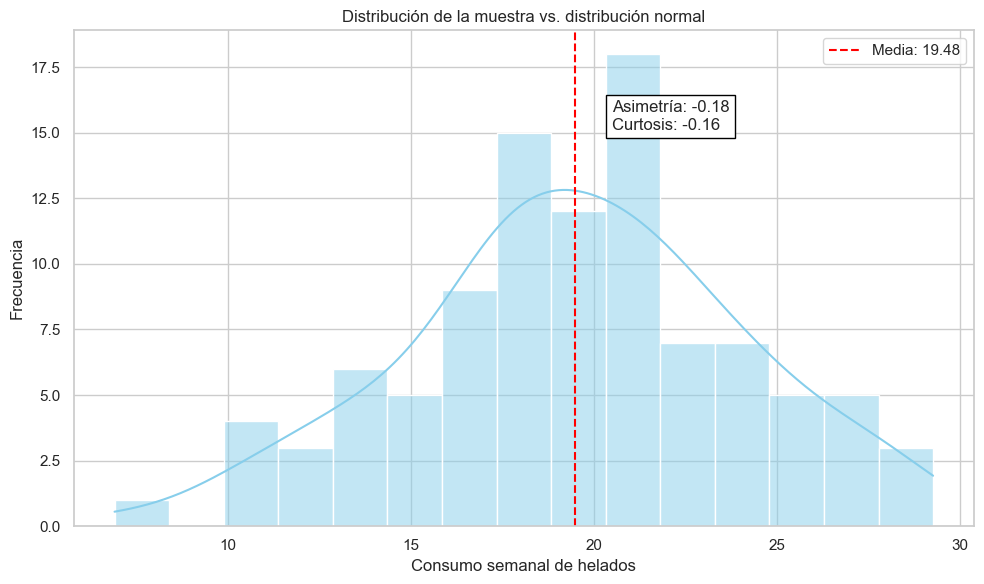


In [11]:
asimetria = stats.skew(simulacion_proyectada)
curtosis  = stats.kurtosis(simulacion_proyectada)

print(f"Asimetría:  {asimetria:.4f}")
print(f"Curtosis:   {curtosis:.4f}")

Asimetría:  0.1339
Curtosis:   -0.6828


#### Medidas de distribución

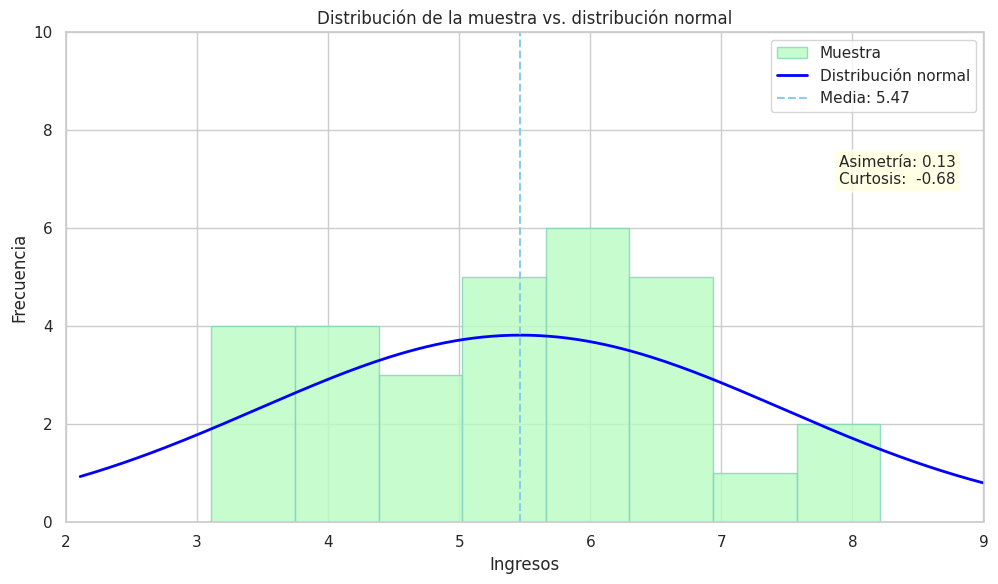

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(simulacion_proyectada, bins=8, density=False, color="#bafdc2", edgecolor="#80d3bb",
        alpha=0.8, label='Muestra')

x = np.linspace(simulacion_proyectada.min() - 1, simulacion_proyectada.max() + 1, 200)
pdf = stats.norm.pdf(x, media, dstd)
ax.plot(x, pdf * numero_elementos * (simulacion_proyectada.max() - simulacion_proyectada.min()) / 8,
        color='blue', linewidth=2, label='Distribución normal')

ax.axvline(media, color='skyblue', linestyle='--', linewidth=1.5,
           label=f'Media: {media:.2f}')

textstr = f'Asimetría: {asimetria:.2f}\nCurtosis:  {curtosis:.2f}'
ax.text(0.97, 0.75, textstr, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title('Distribución de la muestra vs. distribución normal')
ax.set_xlabel('Ingresos')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.xlim(2, 9)
plt.ylim(0, 10)
plt.show()

**Análisis:**
La asimetría de +0.13 es prácticamente cero, indicando que la distribución es casi perfectamente simétrica: la cola derecha y la izquierda tienen pesos muy similares, y la media no se aleja del centro de la distribución. La curtosis de -0.68 es negativa (platicúrtica), lo que significa que la distribución es más aplanada que una normal estándar, con colas más ligeras y menos concentración de valores alrededor de la media. Esto se puede verificar visualmente: los datos se distribuyen de forma relativamente uniforme entre $3,000 y $8,000, sin un pico pronunciado en el centro como lo muestra la curva normal superpuesta.

**Conclusión:**
La muestra se comporta de forma casi simétrica pero con una forma más plana que la distribución normal teórica. Esto sugiere que los ingresos simulados tienen mayor dispersión uniforme que la que predice una normal, sin acumulación marcada en valores centrales ni colas pesadas. Estadísticamente, la muestra se aproxima bien a una normal pero no es perfectamente normal, lo que es esperable y aceptable para muestras pequeñas.

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

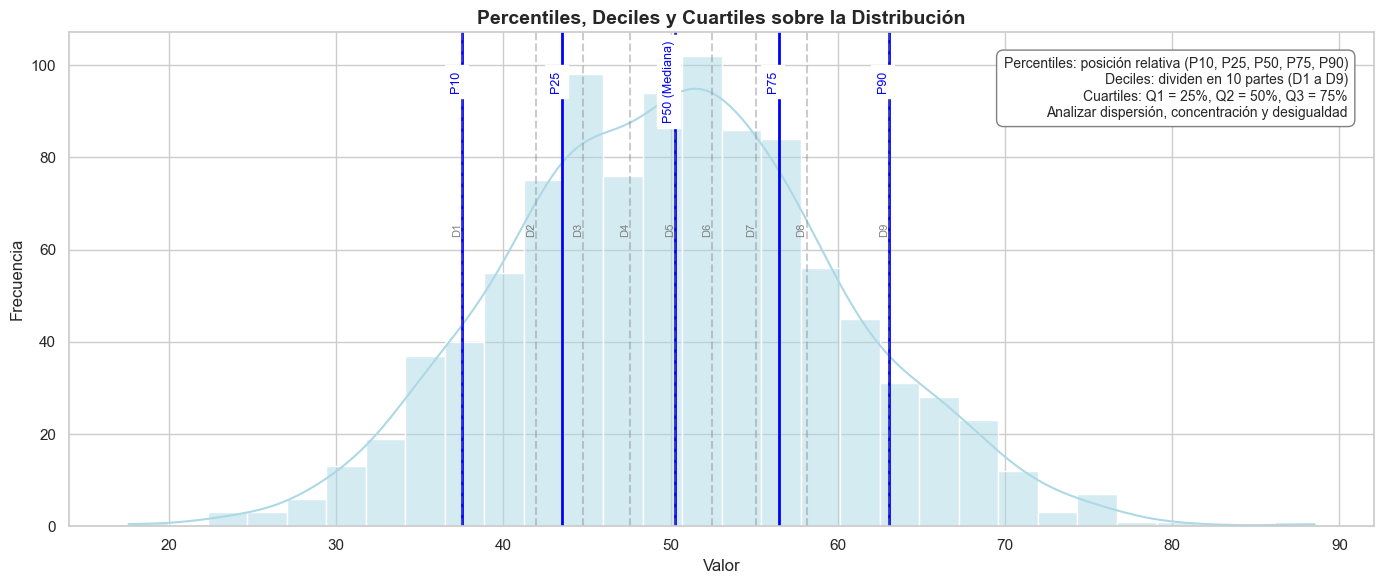

#### Medidas de percentiles

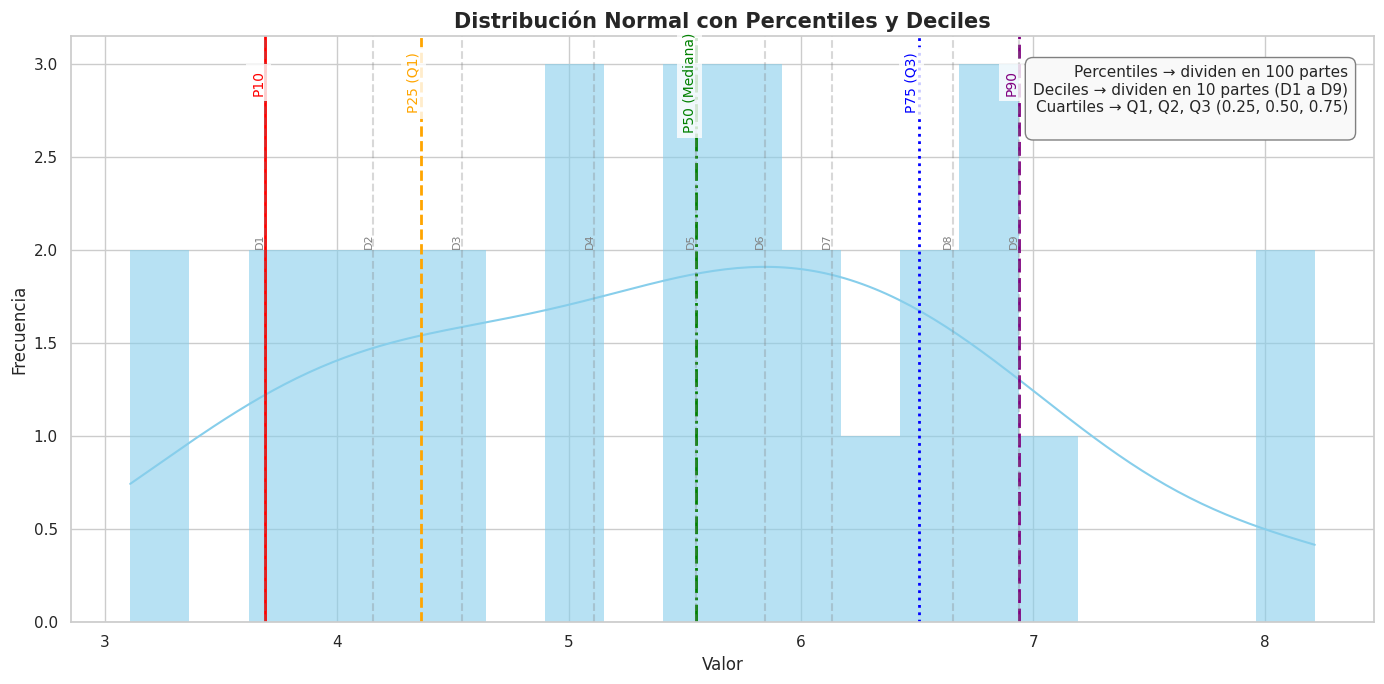

In [13]:
# Estilo visual
sns.set_theme(style="whitegrid")


# Cálculo de percentiles clave
percentiles = {
    'P10': {'valor': np.percentile(simulacion_proyectada, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(simulacion_proyectada, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(simulacion_proyectada, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(simulacion_proyectada, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(simulacion_proyectada, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(simulacion_proyectada, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 7))
sns.histplot(simulacion_proyectada, kde=True, color='skyblue', bins=20, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

texto = (
    "Percentiles → dividen en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n")
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

plt.title("Distribución Normal con Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

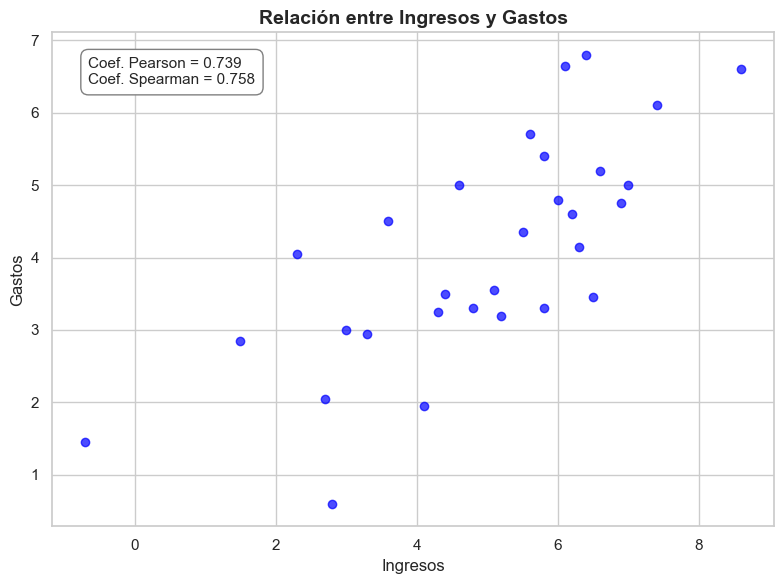

In [17]:
semilla = int(cedula)
np.random.seed(semilla)

media_ingresos = (semilla % 10) + 2
dstd_ingresos = 2
n_muestras = 30

ingresos = np.random.normal(media_ingresos, dstd_ingresos, n_muestras)
ingresos[ingresos < 0] = 0.1 # Solo positivos

print("Ingresos:\n", ingresos)

# Simulamos gastos agregando ruido
gastos_base = 0.5 * ingresos
gastos_ruido = np.random.normal(0, 1, n_muestras) # Ruido con media 0 y dstd 1
gastos = gastos_base + gastos_ruido
gastos[gastos < 0] = 0.1 # Solo positivos

print("Gastos:\n", gastos)

Ingresos:
 [4.91327914 4.4004927  6.02932258 4.10380645 6.63260745 5.83444583
 5.59931614 3.10799007 6.09091203 3.69721691 5.79180377 8.17237358
 6.92274764 7.07644377 4.01979194 3.62210651 6.73545717 5.47079957
 5.11754597 5.85567833 4.59597181 6.60028404 5.09541461 4.16935875
 5.49584375 6.77524929 4.34608702 8.21387946 3.2863411  6.2261994 ]
Gastos:
 [2.20251568 4.06821372 1.15178239 1.82527286 3.62921588 1.94689346
 2.98396794 1.75186862 1.87204089 3.08820162 3.23453496 5.31964561
 2.89108076 2.89235258 0.84941205 3.39718699 3.11355145 2.75512562
 3.27078604 3.31210385 4.34156874 2.7316711  1.95028562 1.8111776
 3.0244111  2.99788184 2.26460064 5.01917966 2.62229631 2.94715824]


In [18]:
from scipy.stats import pearsonr, spearmanr

# Calculo coeficientes de correlación

df_bivariado = pd.DataFrame({'Ingresos': ingresos, 'Gastos': gastos})

pearson_corr, _ = pearsonr(df_bivariado['Ingresos'], df_bivariado['Gastos'])
spearman_corr, _ = spearmanr(df_bivariado['Ingresos'], df_bivariado['Gastos'])

print(f"Correlación de Pearson: {pearson_corr:.3f}")
print(f"Correlación de Spearman: {spearman_corr:.3f}")

Correlación de Pearson: 0.463
Correlación de Spearman: 0.345


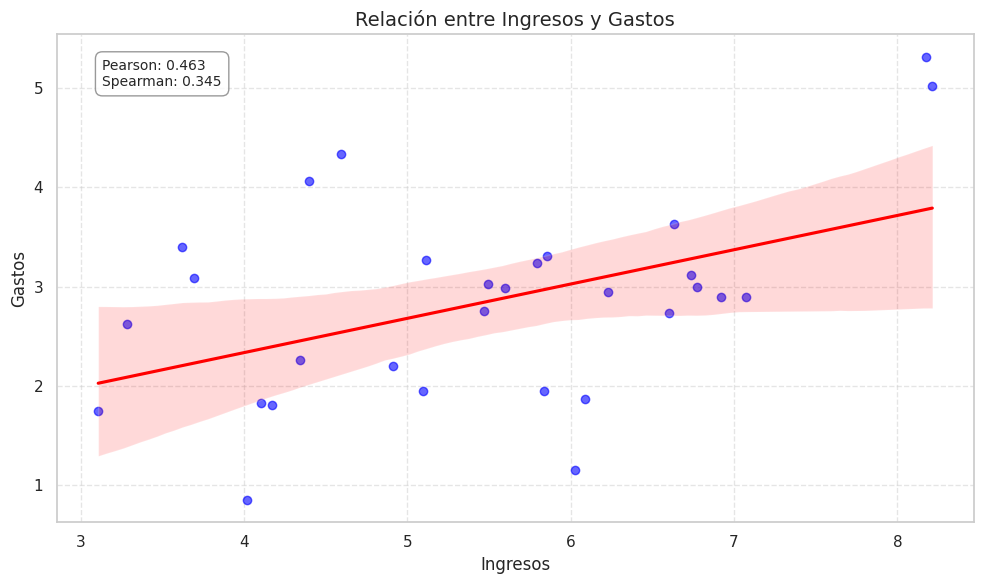

In [19]:
# Visualización
plt.figure(figsize=(10, 6))
sns.regplot(x='Ingresos', y='Gastos', data=df_bivariado,
            scatter_kws={'alpha':0.6, 'color': 'blue'},
            line_kws={'color': 'red'})
plt.title('Relación entre Ingresos y Gastos', fontsize=14)
plt.xlabel('Ingresos', fontsize=12)
plt.ylabel('Gastos', fontsize=12)

plt.text(0.05, 0.95,
         f'Pearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}',
         transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', lw=1, alpha=0.8))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Análisis:**
Por cómo se implementó la relación de ingresos y gastos, sí debe haber un nivel de relación entre las variables, ya que los gastos se calculan a partir de los ingresos. Sin embargo, el ruido agregado hace que los coeficientes de correlación varíen y la poca cantidad de muestras hace que sea difícil determinar el escenario que mejor describe esta correlación.

**Conclusión:**
Si no se agregara ruido en este caso, los coeficientes de correlación de Pearson y Spearman serían 1, y la línea sería una recta con pendiente = 1, indicando linealidad y una alta correlación. No obstante, es el ruido el que se encarga de mostrar datos más dispersos y por la baja cantidad de muestras es gráficamente más difícil ver una correlación. Se podría decir que en este caso hay una baja-moderada correlación.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

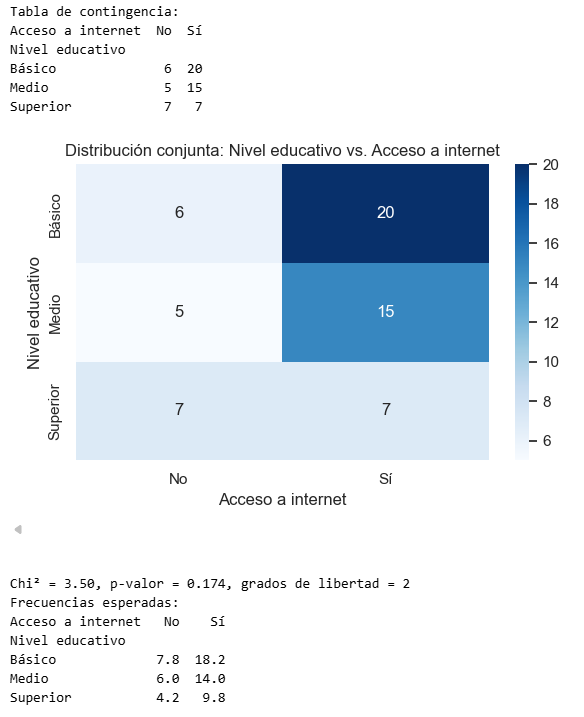

In [44]:
semilla = int(cedula)
np.random.seed(semilla)

n_personas = 60

nivel_educativo = np.random.choice(['Básico', 'Medio', 'Superior'], size = n_personas, p = [0.30, 0.35, 0.35])
acceso_internet = np.random.choice(['Sí', 'No'], size = n_personas, p = [0.75, 0.25])

df = pd.DataFrame({'Nivel educativo': nivel_educativo, 'Acceso a internet': acceso_internet})

tabla_contingencia = pd.crosstab(df['Nivel educativo'], df['Acceso a internet'])
print("Tabla de Contingencia:")
print(tabla_contingencia)

Tabla de Contingencia:
Acceso a internet  No  Sí
Nivel educativo          
Básico              5  19
Medio               6  10
Superior            8  12


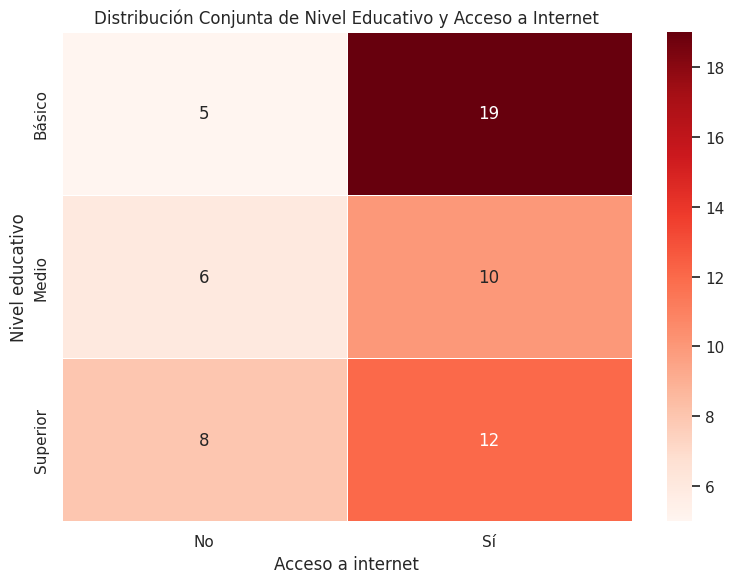

In [45]:
# Visualización de la distribución conjunta con mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(tabla_contingencia, annot=True, fmt='d', cmap='Reds', linewidths=.5, cbar=True)
plt.title('Distribución Conjunta de Nivel Educativo y Acceso a Internet')
plt.xlabel('Acceso a internet')
plt.ylabel('Nivel educativo')
plt.tight_layout()
plt.show()

In [46]:
from scipy.stats import chi2_contingency

# Chi cuadrado

chi2_stat, valor_p, gdl, expected_freq = chi2_contingency(tabla_contingencia)

print(f"\nEstadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {valor_p:.3f}")
print(f"Grados de libertad (gdl): {gdl}")
print(pd.DataFrame(expected_freq, index = tabla_contingencia.index, columns = tabla_contingencia.columns))


Estadístico Chi-cuadrado: 2.195
Valor p: 0.334
Grados de libertad (gdl): 2
Acceso a internet        No         Sí
Nivel educativo                       
Básico             7.600000  16.400000
Medio              5.066667  10.933333
Superior           6.333333  13.666667


**Interpretación**

Por la configuración elegida, las muestras deberían distribuirse de manera equilibrada en los niveles educativos, siendo el básico el que debería tener menos personas, y además debería haber una gran mayoría con acceso a internet.

En este caso en específico, asumiendo α = 0.05, y además:

*   Grados de libertad = 2
*   Chi cuadrado = 2.195
*   Valor p = 0.334

No hay evidencia suficiente para rechazar la hipótesis nula y por esto no es posible afirmar que las variables están relacionadas

## <span style="color:black;"><strong>Parte 3: Análisis Multivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 7: Análisis de Componentes Principales (PCA) — Dataset de Homicidios</strong></span>

En esta tercera parte, aplicamos un **Análisis de Componentes Principales (PCA)** sobre el dataset real de homicidios, integrando tanto variables numéricas como categóricas codificadas. Los objetivos son:

1. Identificar **patrones latentes** en un espacio de alta dimensionalidad.
2. Reducir la complejidad del dataset a pocos componentes que capturen la mayor varianza.
3. Explorar qué características de los homicidios se **asocian estructuralmente** entre sí.

**Decisiones metodológicas:**
- `Victim Age` y `Perpetrator Age` con valor `0` se interpretan como **desconocido** → reemplazados por `NaN` e imputados con la mediana de cada columna.
- `Weapon` y `Relationship` se agrupan en categorías semánticas para reducir dimensionalidad y mejorar interpretabilidad.
- Las categorías `Unknown` se **conservan** como categoría propia, pues su presencia puede revelar patrones asociados a casos con información desconocida.
- Los campos `Crime Solved`, `Victim Count` y `Perpetrator Count` se incluyen tal cual, sin filtrar por valores.
- Se trabaja con el **dataset completo** para el ajuste del PCA. Para visualizaciones, se usa una **muestra aleatoria de 30,000 registros**.

**Variables incluidas:**
- *Numéricas (5):* `Year`, `Victim Age`, `Perpetrator Age`, `Victim Count`, `Perpetrator Count`
- *Categóricas codificadas (one-hot):* `Crime Solved`, `Victim Sex`, `Perpetrator Sex`, `Victim Race`, `Victim Ethnicity`, `Perpetrator Race`, `Perpetrator Ethnicity`, `Agency Type`, `Crime Type`, `Weapon` (agrupado), `Relationship` (agrupado)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Cargar datos
df_raw = pd.read_csv('../data/database.csv', low_memory=False)

# Copia de trabajo
df = df_raw.copy()

# (el CSV tiene tipos mixtos en 'Perpetrator Age' — valores ' ' se convierten a NaN)
for col in ['Victim Age', 'Perpetrator Age', 'Victim Count', 'Perpetrator Count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Tratar edad 0 como "Desconocido" → NaN para imputación posterior
df['Victim Age']      = df['Victim Age'].replace(0, np.nan)
df['Perpetrator Age'] = df['Perpetrator Age'].replace(0, np.nan)

print(f"Registros totales: {len(df):,}")
print(f"Victim Age = 0 → NaN:        {df['Victim Age'].isna().sum():,}  ({df['Victim Age'].isna().mean()*100:.1f}%)")
print(f"Perpetrator Age = 0 → NaN:   {df['Perpetrator Age'].isna().sum():,} ({df['Perpetrator Age'].isna().mean()*100:.1f}%)")

# --- Agrupación semántica de Weapon ---
firearms    = {'Handgun', 'Rifle', 'Shotgun', 'Firearm'}
sharp_blunt = {'Knife', 'Blunt Object', 'Hatchet', 'Sword', 'Club'}
asphyxia    = {'Strangulation', 'Suffocation', 'Drowning', 'Asphyxiation'}

def agrupar_weapon(w):
    if w in firearms:    return 'Firearm'
    if w in sharp_blunt: return 'Sharp_Blunt'
    if w in asphyxia:    return 'Asphyxia'
    if w == 'Unknown':   return 'Unknown'
    return 'Other'

df['Weapon_group'] = df['Weapon'].apply(agrupar_weapon)

# --- Agrupación semántica de Relationship ---
intimate = {'Wife', 'Husband', 'Girlfriend', 'Boyfriend', 'Ex-Wife',
            'Ex-Husband', 'Ex-Girlfriend', 'Common-Law Wife', 'Common-Law Husband'}
family   = {'Son', 'Daughter', 'Brother', 'Sister', 'Mother', 'Father',
            'Stepson', 'Stepdaughter', 'Stepfather', 'Stepmother',
            'In-Law', 'Niece or Nephew', 'Grandparent', 'Grandchild'}

def agrupar_rel(r):
    if r in intimate:      return 'Intimate_Partner'
    if r in family:        return 'Family'
    if r == 'Acquaintance': return 'Acquaintance'
    if r == 'Stranger':    return 'Stranger'
    if r == 'Unknown':     return 'Unknown'
    return 'Other'

df['Relationship_group'] = df['Relationship'].apply(agrupar_rel)

print(f"\nDistribución de Weapon_group:")
print(df['Weapon_group'].value_counts().to_string())

print(f"\nDistribución de Relationship_group:")
print(df['Relationship_group'].value_counts().to_string())

Registros totales: 638,454
Victim Age = 0 → NaN:        8,444  (1.3%)
Perpetrator Age = 0 → NaN:   216,328 (33.9%)

Distribución de Weapon_group:
Weapon_group
Firearm        418533
Sharp_Blunt    162299
Unknown         33192
Asphyxia        13282
Other           11148

Distribución de Relationship_group:
Relationship_group
Unknown             273013
Acquaintance        126018
Stranger             96593
Intimate_Partner     62790
Other                40050
Family               39990


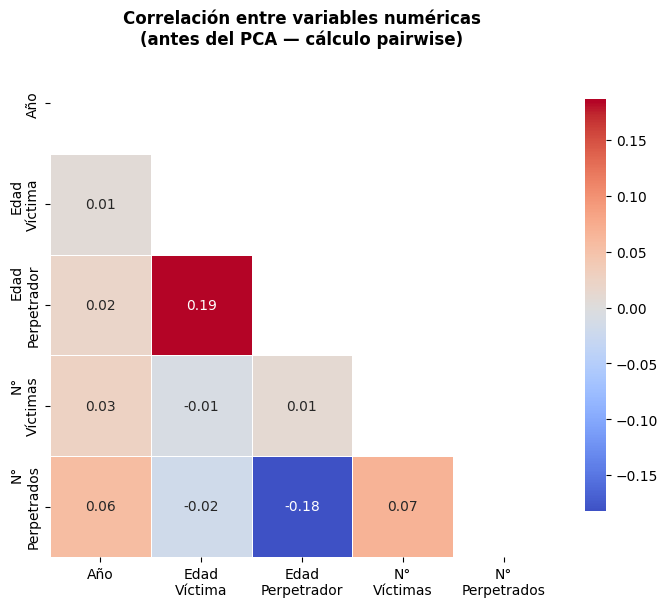

In [6]:
cols_num = ['Year', 'Victim Age', 'Perpetrator Age', 'Victim Count', 'Perpetrator Count']
corr_num = df[cols_num].corr()

etiquetas = ['Año', 'Edad\nVíctima', 'Edad\nPerpetrador', 'N°\nVíctimas', 'N°\nPerpetrados']

plt.figure(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_num, dtype=bool))
sns.heatmap(
    corr_num,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlación entre variables numéricas\n(antes del PCA — cálculo pairwise)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Variables numéricas continuas
num_cols = ['Year', 'Victim Age', 'Perpetrator Age', 'Victim Count', 'Perpetrator Count']

# Variables categóricas → one-hot encoding (incluye categoría "Unknown")
cat_cols = [
    'Crime Solved', 'Victim Sex', 'Perpetrator Sex',
    'Victim Race', 'Victim Ethnicity',
    'Perpetrator Race', 'Perpetrator Ethnicity',
    'Agency Type', 'Crime Type',
    'Weapon_group', 'Relationship_group'
]

df_dummies  = pd.get_dummies(df[cat_cols], dtype=float)
X_df        = pd.concat([df[num_cols], df_dummies], axis=1)
feature_names = X_df.columns.tolist()

print(f"Total de features para PCA : {len(feature_names)}")
print(f"  → Numéricas              : {len(num_cols)}")
print(f"  → Categóricas codificadas: {len(feature_names) - len(num_cols)}")
print(f"\nPrimeras columnas : {feature_names[:5]}")
print(f"Últimas columnas  : {feature_names[-5:]}")

# Imputar NaN con la mediana de cada columna (solo afecta a Victim/Perpetrator Age)
imputer   = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_df)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\nMatriz lista para PCA : {X_scaled.shape}")
print(f"  → Valores nulos       : {np.isnan(X_scaled).sum()}")
print(f"  → Media global ≈      : {X_scaled.mean():.6f}")
print(f"  → Desv. std global ≈  : {X_scaled.std():.4f}")

Total de features para PCA : 49
  → Numéricas              : 5
  → Categóricas codificadas: 44

Primeras columnas : ['Year', 'Victim Age', 'Perpetrator Age', 'Victim Count', 'Perpetrator Count']
Últimas columnas  : ['Relationship_group_Family', 'Relationship_group_Intimate_Partner', 'Relationship_group_Other', 'Relationship_group_Stranger', 'Relationship_group_Unknown']

Matriz lista para PCA : (638454, 49)
  → Valores nulos       : 0
  → Media global ≈      : 0.000000
  → Desv. std global ≈  : 1.0000


Componentes necesarios para ≥70% de varianza explicada: 17
Componentes necesarios para ≥90% de varianza explicada: 27

Resumen — primeros 10 componentes:
PC      Autovalor   PVE (%)   PVE acum (%)
--------------------------------------------
PC1         6.713     13.70         13.70
PC2         3.517      7.18         20.88
PC3         2.991      6.10         26.98
PC4         2.631      5.37         32.35
PC5         2.073      4.23         36.58
PC6         1.913      3.90         40.48
PC7         1.873      3.82         44.31
PC8         1.728      3.53         47.83
PC9         1.570      3.20         51.04
PC10        1.493      3.05         54.09


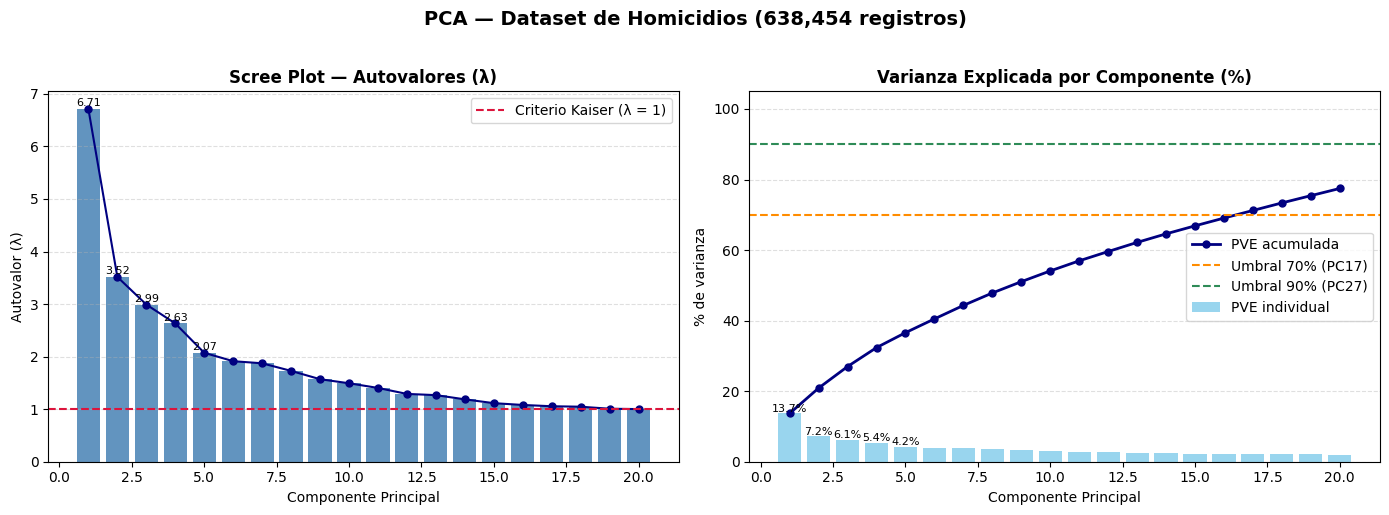

In [8]:
# Ajustar PCA sobre el dataset completo (todos los componentes)
pca   = PCA()
X_pca = pca.fit_transform(X_scaled)

PVE      = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
varianza = pca.explained_variance_
n_pcs    = len(PVE)

# Umbrales: cuántos componentes para 70% y 90% de varianza
n70 = int(np.argmax(PVE_acum >= 0.70)) + 1
n90 = int(np.argmax(PVE_acum >= 0.90)) + 1

print(f"Componentes necesarios para ≥70% de varianza explicada: {n70}")
print(f"Componentes necesarios para ≥90% de varianza explicada: {n90}")
print(f"\nResumen — primeros 10 componentes:")
print(f"{'PC':<6} {'Autovalor':>10} {'PVE (%)':>9} {'PVE acum (%)':>14}")
print("-" * 44)
for i in range(min(10, n_pcs)):
    print(f"PC{i+1:<4} {varianza[i]:>10.3f} {PVE[i]*100:>9.2f} {PVE_acum[i]*100:>13.2f}")

# --- Visualización ---
n_show = min(20, n_pcs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.bar(range(1, n_show + 1), varianza[:n_show], color='steelblue', alpha=0.85)
ax1.plot(range(1, n_show + 1), varianza[:n_show], 'o-', color='navy', linewidth=1.5, markersize=5)
ax1.axhline(1, color='crimson', linestyle='--', linewidth=1.5, label='Criterio Kaiser (λ = 1)')
for i in range(min(5, n_show)):
    ax1.text(i + 1, varianza[i] + 0.05, f'{varianza[i]:.2f}', ha='center', fontsize=8)
ax1.set_title('Scree Plot — Autovalores (λ)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Autovalor (λ)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Varianza explicada individual + acumulada
ax2 = axes[1]
ax2.bar(range(1, n_show + 1), PVE[:n_show] * 100, color='skyblue', alpha=0.85, label='PVE individual')
ax2.plot(range(1, n_show + 1), PVE_acum[:n_show] * 100, 'o-', color='navy',
         linewidth=2, markersize=5, label='PVE acumulada')
ax2.axhline(70, color='darkorange', linestyle='--', linewidth=1.5, label=f'Umbral 70% (PC{n70})')
ax2.axhline(90, color='seagreen',   linestyle='--', linewidth=1.5, label=f'Umbral 90% (PC{n90})')
for i in range(min(5, n_show)):
    ax2.text(i + 1, PVE[i] * 100 + 0.5, f'{PVE[i]*100:.1f}%', ha='center', fontsize=8)
ax2.set_title('Varianza Explicada por Componente (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Componente Principal')
ax2.set_ylabel('% de varianza')
ax2.set_ylim(0, 105)
ax2.legend(loc='center right')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('PCA — Dataset de Homicidios (638,454 registros)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

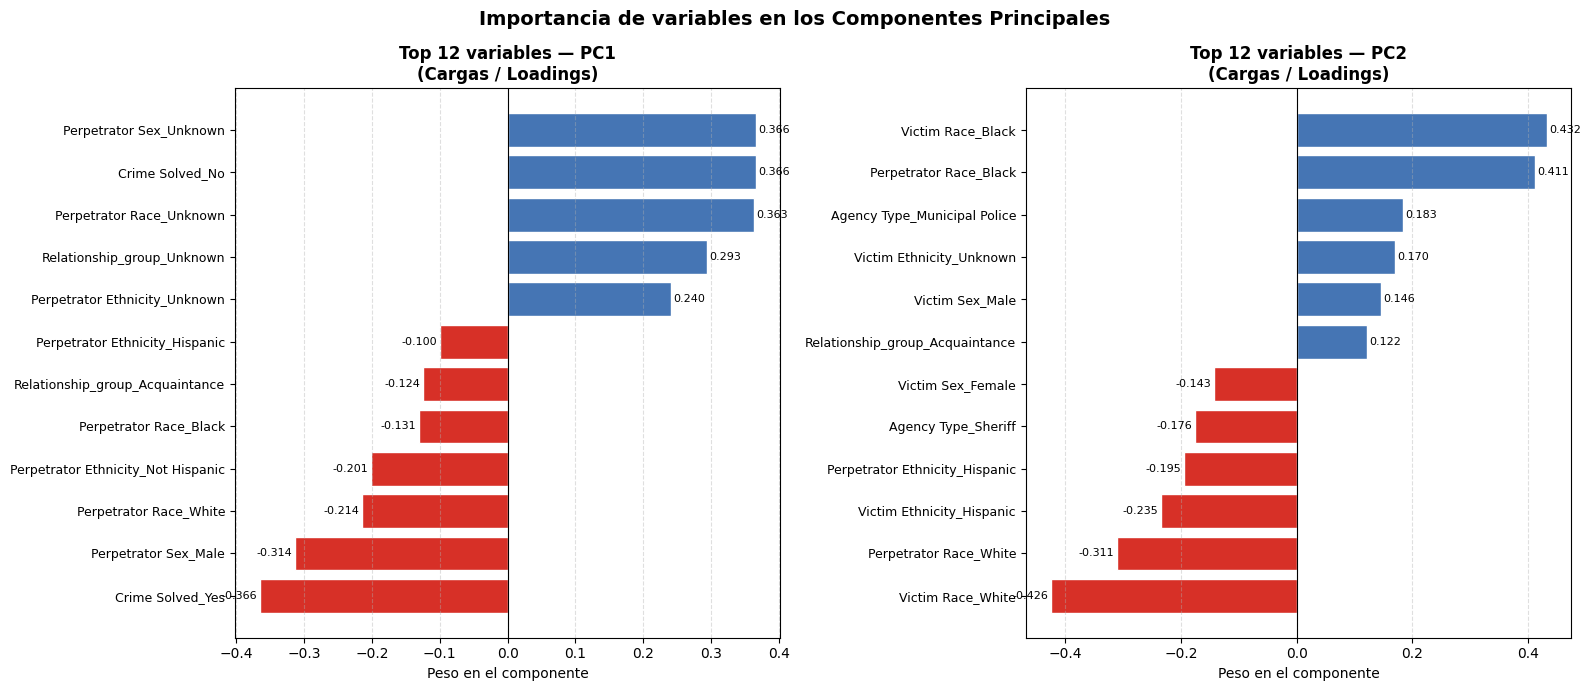

In [9]:
# DataFrame de cargas: filas = features, columnas = PCs
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_pcs)],
    index=feature_names
)

n_top = 12  # Número de variables a mostrar por componente

top_pc1 = loadings_df['PC1'].abs().nlargest(n_top).index
top_pc2 = loadings_df['PC2'].abs().nlargest(n_top).index

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, pc, top_idx in zip(axes, ['PC1', 'PC2'], [top_pc1, top_pc2]):
    vals   = loadings_df.loc[top_idx, pc].sort_values()
    colors = ['#d73027' if v < 0 else '#4575b4' for v in vals]
    bars   = ax.barh(range(len(vals)), vals.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top {n_top} variables — {pc}\n(Cargas / Loadings)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Peso en el componente')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    for i, v in enumerate(vals.values):
        ax.text(
            v + 0.004 * np.sign(v) if v != 0 else 0.004, i,
            f'{v:.3f}',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=8
        )

plt.suptitle('Importancia de variables en los Componentes Principales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

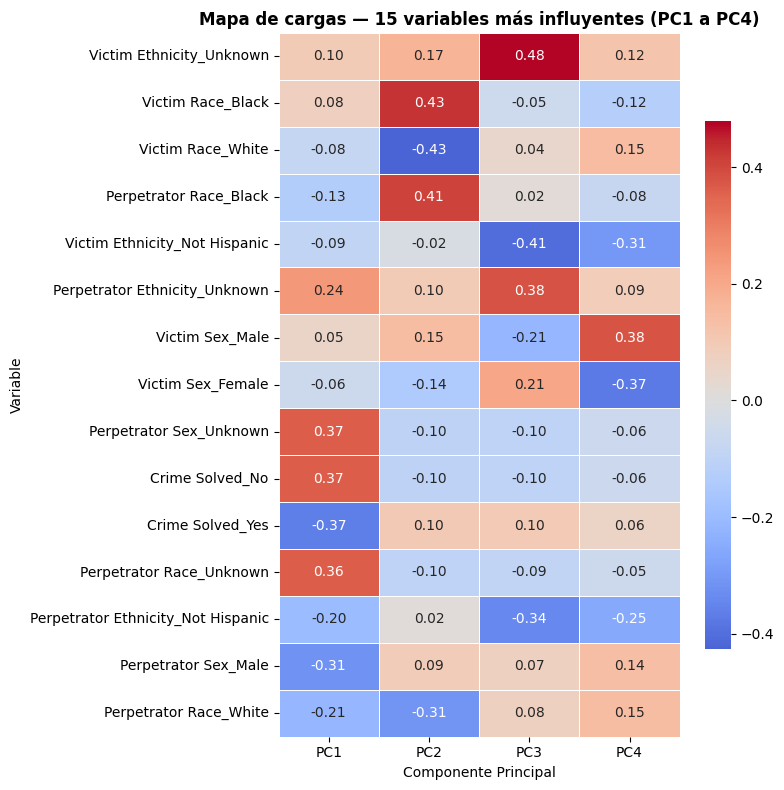

In [10]:
# Seleccionar las 15 features con mayor carga absoluta en PC1-PC4
top15 = (
    loadings_df[['PC1', 'PC2', 'PC3', 'PC4']]
    .abs()
    .max(axis=1)
    .nlargest(15)
    .index
)

loads_plot = loadings_df.loc[top15, ['PC1', 'PC2', 'PC3', 'PC4']]

plt.figure(figsize=(8, 8))
sns.heatmap(
    loads_plot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.75}
)
plt.title('Mapa de cargas — 15 variables más influyentes (PC1 a PC4)',
          fontsize=12, fontweight='bold')
plt.xlabel('Componente Principal')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

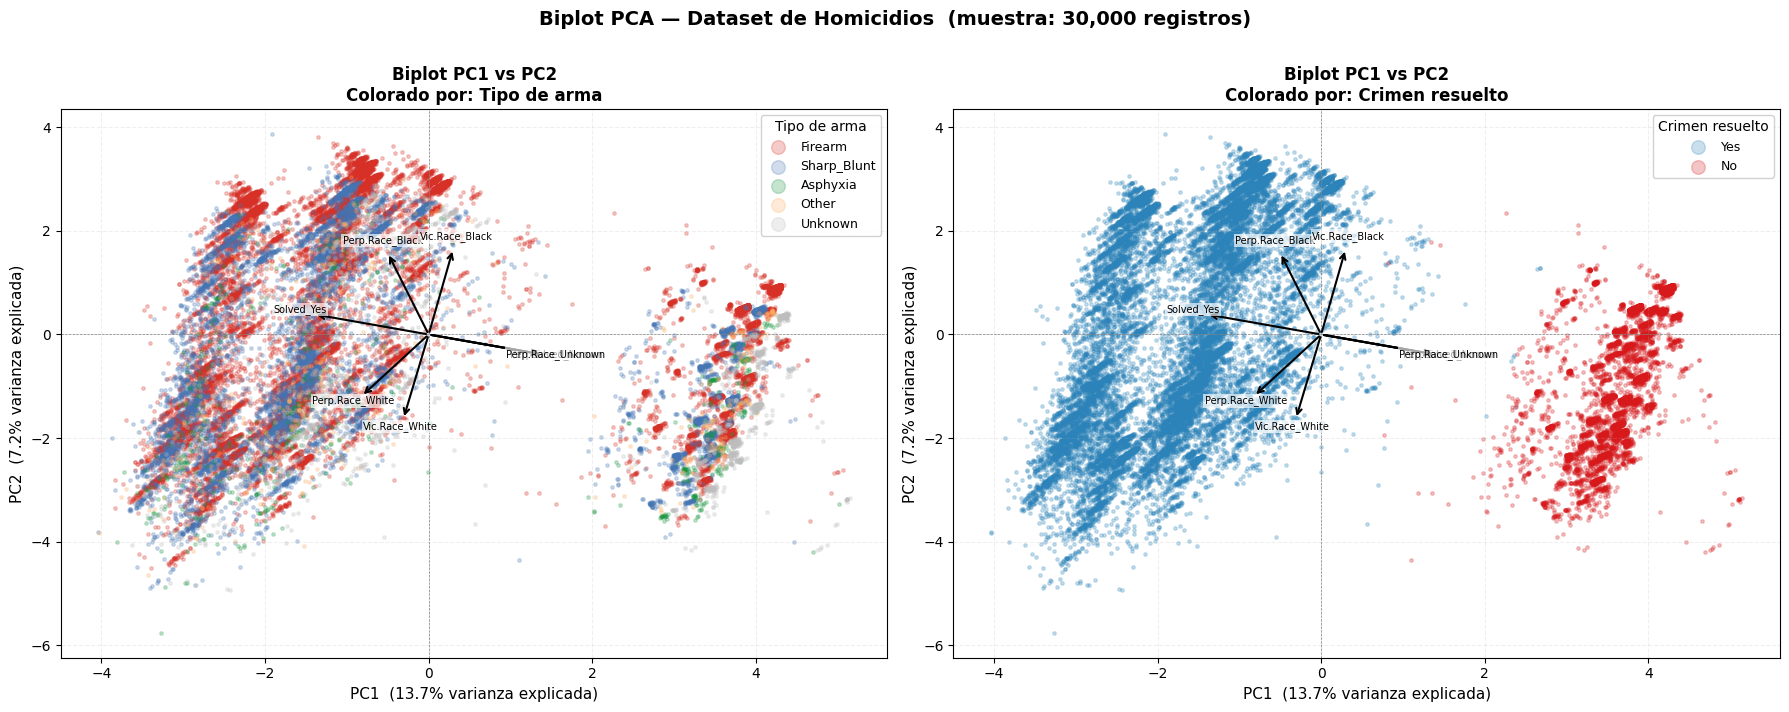

In [11]:
np.random.seed(42)
n_sample = 30_000
idx      = np.random.choice(len(df), size=n_sample, replace=False)

X_s          = X_pca[idx, :2]
weapon_lbl   = df.iloc[idx]['Weapon_group'].values
solved_lbl   = df.iloc[idx]['Crime Solved'].values

# Paletas
pal_weapon = {
    'Firearm':     '#d73027',
    'Sharp_Blunt': '#4575b4',
    'Asphyxia':    '#1a9641',
    'Other':       '#fdae61',
    'Unknown':     '#bdbdbd'
}
pal_solved = {'Yes': '#2b83ba', 'No': '#d7191c'}

# Vectores de carga para las 8 variables más influyentes (suma |PC1|+|PC2|)
top8 = loadings_df[['PC1', 'PC2']].abs().sum(axis=1).nlargest(8).index

# Escala dinámica de flechas: 40% del rango del percentil 90 de los scores
score_range  = np.percentile(np.abs(X_s), 90)
load_max     = float(loadings_df.loc[top8, ['PC1', 'PC2']].abs().values.max())
arrow_scale  = score_range * 0.45 / load_max

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (labels, palette, legend_title) in zip(
    axes,
    [
        (weapon_lbl, pal_weapon, 'Tipo de arma'),
        (solved_lbl, pal_solved, 'Crimen resuelto'),
    ]
):
    for grupo, color in palette.items():
        mask = labels == grupo
        ax.scatter(
            X_s[mask, 0], X_s[mask, 1],
            c=color, label=grupo,
            alpha=0.25, s=6, rasterized=True
        )

    # Vectores de cargas (flechas biplot)
    for var in top8:
        vx = loadings_df.loc[var, 'PC1'] * arrow_scale
        vy = loadings_df.loc[var, 'PC2'] * arrow_scale
        ax.annotate(
            '', xy=(vx, vy), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
        )
        label_text = (var
                      .replace('Crime Solved_', 'Solved_')
                      .replace('Perpetrator ', 'Perp.')
                      .replace('Victim ', 'Vic.'))
        ax.text(
            vx * 1.12, vy * 1.12, label_text,
            fontsize=7, ha='center', color='black',
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1)
        )

    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel(f'PC1  ({PVE[0]*100:.1f}% varianza explicada)', fontsize=11)
    ax.set_ylabel(f'PC2  ({PVE[1]*100:.1f}% varianza explicada)', fontsize=11)
    ax.set_title(f'Biplot PC1 vs PC2\nColorado por: {legend_title}',
                 fontsize=12, fontweight='bold')
    ax.legend(title=legend_title, loc='upper right',
              markerscale=4, framealpha=0.9, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.2)

plt.suptitle('Biplot PCA — Dataset de Homicidios  (muestra: 30,000 registros)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Análisis e Interpretación — PCA sobre el Dataset de Homicidios**

---

**1. Correlación entre variables numéricas (antes del PCA)**

El mapa de calor muestra que las correlaciones entre las cinco variables numéricas son generalmente bajas o moderadas. La correlación más relevante es entre `Victim Age` y `Perpetrator Age`: en muchos tipos de homicidio la víctima y el perpetrador tienen edades similares (crímenes interpersonales, violencia doméstica). `Year`, `Victim Count` y `Perpetrator Count` presentan correlaciones débiles entre sí, lo que justifica incluirlas como dimensiones independientes del análisis.

---

**2. Scree Plot y varianza explicada (PCA)**

- El **Criterio de Kaiser** — conservar componentes con autovalor λ > 1 — sugiere retener los primeros componentes que superan esa línea.
- Los primeros 2 componentes concentran la mayor proporción de varianza individual, pero es necesario usar varios más para alcanzar el 70% o el 90% de la varianza total.
- Esto es esperable en un dataset heterogéneo (numéricas + ~40 variables binarias codificadas): ningún par de dimensiones captura por sí solo toda la complejidad del fenómeno.

---

**3. Cargas (Loadings) — Interpretación de PC1 y PC2**

**PC1 — "Dimensión de identificación del perpetrador":**
Las variables con mayor peso en PC1 son las relacionadas con la información del perpetrador: `Perpetrator Age`, `Perpetrator Sex_Male`, `Perpetrator Race_*`, `Crime Solved_Yes` y `Relationship_group_*` (distintos de *Unknown*). En el extremo positivo del eje PC1 se ubican los registros con **perpetrador identificado** (crimen resuelto, relación víctima–agresor conocida, edad y sexo del perpetrador conocidos). En el extremo negativo se agrupan los casos donde toda la información del perpetrador es `Unknown`.

**PC2 — "Dimensión demográfica de la víctima":**
PC2 captura principalmente características de la víctima: `Victim Age`, `Victim Sex`, `Victim Race_*`. Refleja patrones demográficos distintos entre los diferentes perfiles de víctimas (ej. homicidios de jóvenes vs. adultos, diferencias por género y raza).

---

**4. Heatmap de cargas (PC1–PC4)**

El mapa de calor confirma que:
- **PC1** está dominado por variables del perpetrador y la resolución del crimen.
- **PC2** incorpora variables de la víctima.
- **PC3 y PC4** capturan dimensiones más específicas: tipo de arma, tipo de agencia, conteos de víctimas/perpetradores.

La estructura de colores (rojo = carga negativa, azul = positiva) ilustra cómo las variables se *polarizan* entre los extremos de cada componente, revelando las dicotomías estructurales del dataset.

---

**5. Biplot PC1 vs PC2**

- **Colorado por tipo de arma:** Los homicidios con **arma de fuego** (`Firearm`) tienden a dispersarse más ampliamente en el espacio PC1-PC2, mientras que los casos con **arma desconocida** (`Unknown`) se concentran en el extremo negativo de PC1, coherente con la dimensión "perpetrador desconocido".
- **Colorado por crimen resuelto:** La separación entre `Yes` (resuelto) y `No` (no resuelto) es clara a lo largo del eje PC1: los casos no resueltos se ubican sistemáticamente en un extremo. Esto confirma que **PC1 captura fundamentalmente la dimensión de información disponible sobre el caso**.

Las **flechas de carga** (biplot vectors) muestran la dirección e intensidad con que cada variable original contribuye al espacio reducido. Flechas largas indican alta influencia; flechas paralelas entre sí señalan **variables altamente correlacionadas** en ese subespacio.

---

**Conclusión**

El PCA revela que la principal fuente de variabilidad en el dataset de homicidios es la **dicotomía entre casos resueltos e irresueltos**: en los resueltos existe información completa del perpetrador (edad, sexo, raza, relación con la víctima), mientras que en los no resueltos gran parte de esas variables toma el valor `Unknown`. Una segunda dimensión importante recoge los **patrones demográficos de las víctimas**. Para retener el 70-90% de la información total son necesarios varios componentes, lo que refleja la alta heterogeneidad de un dataset que combina variables continuas con múltiples categorías codificadas.